In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
#Import Data
path= "C:\\Users\\neuma\\OneDrive\\Desktop\\Instacart Basket Anlysis\\02 Data\\Prepared Data\\df_prods_ords_cust_merge.pkl"

In [3]:
#Rename df_ords_prods_cust_merge 
df=pd.read_pickle(os.path.join(path))

Consider any security implications that might exist for this new data. You’ll need to address any PII data in the data before continuing your analysis.

#Answer

Since I still have the data to re-create a full merge if neccessary I already dropped the 
columns containing the customers first and last name in the previous task. I considered this information to be too
personal (and risky ) and unneccessary for any kind of analysis. 

Columns dropped: First_name, Last_name


#Creating A Region Column

The Instacart officers are interested in comparing customer behavior in different geographic areas.
Create a regional segmentation of the data.
You’ll need to create a “Region” column based on the “State” column from your customers data set.

In [5]:
def region(row):

  if row['STATE'] in ('Maine','New Hampshire','Vermont','Massachusetts','Rhode Island','Connecticut','New York',
                     'Pennsylvania','New Jersey'):
    return 'Northeast'
  elif row['STATE'] in ('Wisconsin','Michigan','Illinois','Indiana','Ohio','North Dakota','South Dakota','Nebraska',
                       'Kansas','Minnesota','Iowa','Missouri'):
    return 'Midwest'
  elif row['STATE'] in ('Delaware','Maryland','District of Columbia','Virginia','West Virginia','North Carolina',
                       'South Carolina','Georgia','Florida','Kentucky','Tennessee','Mississippi','Alabama','Oklahoma',
                       'Texas','Arkansas','Louisiana'):
    return 'SOUTH'
  elif row['STATE'] in ('Idaho','Montana','Wyoming','Nevada','Utah','Colorado','Arizona','New Mexico','Alaska','Washington',
                   'Oregon','California','Hawaii'):
    return 'West'

In [6]:
pd.options.mode.copy_on_write = True

Python originally flagged an issue and essentialy asked for the 'pd.options.mode.copy_on_write = True' function to be excuted ,so I ran it here to avoid that issue.

In [7]:
df['Region'] = df.apply(region, axis=1)

In [8]:
#checking results

In [9]:
df['Region'].value_counts()

Region
SOUTH        10791885
West          8292913
Midwest       7597325
Northeast     5722736
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32404859 entries, 0 to 32404858
Data columns (total 33 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   Unnamed: 0_x            int64   
 1   order_id                int64   
 2   user_id                 int64   
 3   order_number            int64   
 4   orders_day_of_week      int64   
 5   order_time              int64   
 6   days_since_prior_order  float64 
 7   product_id              int64   
 8   add_to_cart_order       int64   
 9   reordered               int64   
 10  _merge                  category
 11  Unnamed: 0_y            int64   
 12  product_name            object  
 13  aisle_id                int64   
 14  department_id           int64   
 15  prices                  float64 
 16  merge_indicator         category
 17  price_range             object  
 18  price_range_loc         object  
 19  busiest_day             object  
 20  busiest_days            object  
 21  order_

In [10]:
#Determine whether there’s a difference in spending habits between the different U.S. regions.

In [10]:
df['spender_mean'] = df.groupby(['user_id'])['prices'].transform(np.mean)

C:\Users\neuma\AppData\Local\Temp\ipykernel_6140\1453802368.py:1: FutureWarning: The provided callable <function mean at 0x0000015E8607BBA0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df['spender_mean'] = df.groupby(['user_id'])['prices'].transform(np.mean)


In [11]:
df.loc[df['spender_mean'] >= 10, 'spending_flag'] = 'High Spender'

In [12]:
df.loc[df['spender_mean'] < 10, 'spending_flag'] = 'Low Spender'

In [13]:
#checking results

In [14]:
df['spending_flag'].value_counts()

spending_flag
Low Spender     31770614
High Spender      634245
Name: count, dtype: int64

- I had to recreate the spending_flag column for it got lost due to confusion which data to continue working with earlier

In [15]:
crosstab = pd.crosstab(df['Region'], df['spending_flag'], dropna = False)

In [16]:
crosstab.to_clipboard()

In [17]:
crosstab.head()

spending_flag,High Spender,Low Spender
Region,,
Midwest,155975,7441350
Northeast,108225,5614511
SOUTH,209691,10582194
West,160354,8132559


In [18]:
crosstab.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\crosstab_regional_spending.csv"))

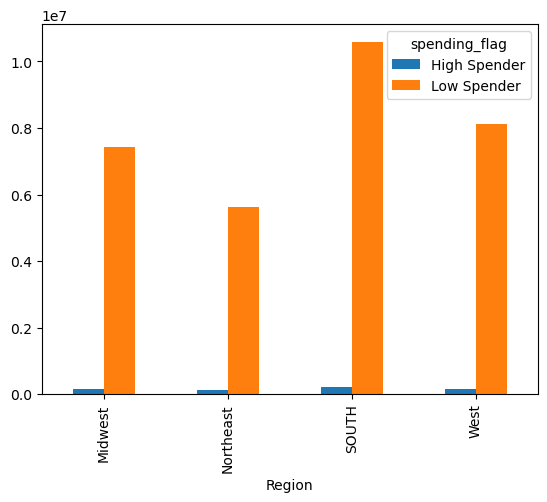

In [19]:
barplot=crosstab.plot.bar()

In [20]:
barplot.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\regional_spending"))

In [22]:
#Next Step of Task

The Instacart CFO isn’t interested in customers who don’t generate much revenue for the app. Create an exclusion flag for low-activity customers (customers with less than 5 orders) and exclude them from the data. Make sure you export this sample.

In [21]:
order_count=df['low_frequency_orders']=df.groupby(['user_id'])['order_id'].transform('count')

In [22]:
df['low_order_frequency']=order_count<5

In [23]:
df.head(10)

,Unnamed: 0_x,order_id,user_id,order_number,orders_day_of_week,order_time,days_since_prior_order,product_id,add_to_cart_order,reordered,...,Age,date_joined,children,fam_status,income,Region,spender_mean,spending_flag,low_frequency_orders,low_order_frequency
0,0,2539329,1,1,2,8,NaN,196,1,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
1,0,2539329,1,1,2,8,NaN,14084,2,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
2,0,2539329,1,1,2,8,NaN,12427,3,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
3,0,2539329,1,1,2,8,NaN,26088,4,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
4,0,2539329,1,1,2,8,NaN,26405,5,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
5,1,2398795,1,2,3,7,15.0,196,1,1,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
6,1,2398795,1,2,3,7,15.0,10258,2,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
7,1,2398795,1,2,3,7,15.0,12427,3,1,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
8,1,2398795,1,2,3,7,15.0,13176,4,0,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False
9,1,2398795,1,2,3,7,15.0,26088,5,1,...,31,2/17/2019,3,married,40423,SOUTH,6.367797,Low Spender,59,False


In [24]:
#creating dataframe sans below 5 order entries

In [25]:
df_1=df[df.groupby('user_id')['order_id'].transform('count')>5]

In [26]:
df.to_pickle(os.path.join(path,"C:\\Users\\neuma\\OneDrive\\Desktop\\Instacart Basket Anlysis\\02 Data\\Prepared Data\\df_merged_low_order_frequencies.pkl"))

In [28]:
#Next Step of Task

 Create a profiling variable based on age, income, certain goods in the “department_id” column, and number of dependents. You might also use the “orders_day_of_week” and “order_hour_of_day” columns if you can think of a way they would impact customer profiles. (Hint: As an example, try thinking of what characteristics would lead you to the profile “Single adult” or “Young parent.”)

In [27]:
def age_group(row):
  
    if row['Age'] <= 35:
        return 'Youth_to_Young_Adults'
    elif row['Age'] <= 60:
        return 'Middle_aged_Adults'
    elif row['Age'] >= 61:
        return 'Eldlier_Adults'

In [28]:
df_1 ['Age_Group']=df_1.apply(age_group, axis=1)

In [29]:
df_1['Age_Group'].value_counts()

Age_Group
Middle_aged_Adults       12673206
Eldlier_Adults           10580743
Youth_to_Young_Adults     9144641
Name: count, dtype: int64

In [30]:
df_1.loc[df_1['income'] >400000, 'income_loc'] = 'High-Income'

In [31]:
df_1.loc[(df_1['income'] <= 400000) & (df_1['income'] > 100000), 'income_loc'] = 'Mid-Income' 

In [32]:
df_1.loc[df_1['income'] <= 100000, 'income_loc'] = 'Low-Income'

In [33]:
#checking results

In [34]:
df_1['income_loc'].value_counts()

income_loc
Low-Income     17586038
Mid-Income     14764860
High-Income       47692
Name: count, dtype: int64

In [35]:
df_1['product_name'], ['department_id']

(0                                              Soda
 1           Organic Unsweetened Vanilla Almond Milk
 2                               Original Beef Jerky
 3                        Aged White Cheddar Popcorn
 4                  XL Pick-A-Size Paper Towel Rolls
                              ...                   
 32404854                               Tomato Paste
 32404855            Brownie Crunch High Protein Bar
 32404856      High Protein Bar Chunky Peanut Butter
 32404857        Chocolate Peanut Butter Protein Bar
 32404858        Roasted & Salted Shelled Pistachios
 Name: product_name, Length: 32398590, dtype: object,
 ['department_id'])

In [36]:
df_1['children'].value_counts()

children
3    8133496
0    8095929
2    8089574
1    8079591
Name: count, dtype: int64

In [37]:
def wards(row):
    
    if row['children']<1:
        return 'Child-free'
    elif row['children']==1:
        return 'Single_ward'
    elif row['children']==2:
        return 'Mid_size_family'
    elif row['children'] >2:
        return 'High_warden_count_Family_'

In [38]:
df_1['Family_Size']=df_1.apply(wards, axis=1)

In [39]:
df_1['Family_Size'].value_counts(dropna=False)

Family_Size
High_warden_count_Family_    8133496
Child-free                   8095929
Mid_size_family              8089574
Single_ward                  8079591
Name: count, dtype: int64

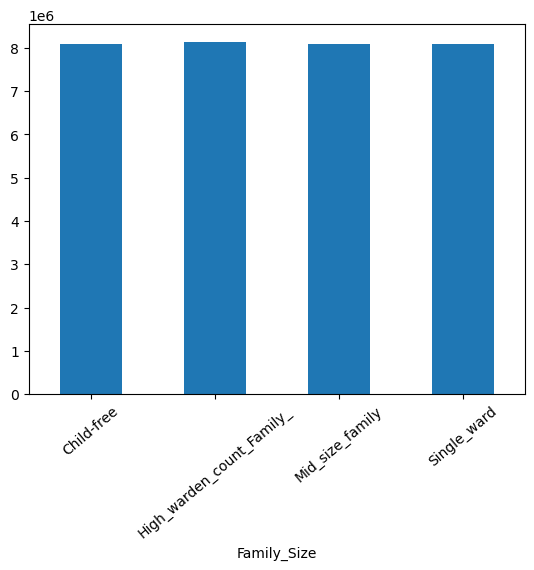

In [40]:
bar = df_1.groupby('Family_Size')['user_id'].count().plot.bar(rot=40)

In [317]:
#creating more crosstabs and charts + saving them

In [41]:
df_1['fam_status'].value_counts()

fam_status
married                             22752378
single                               5324657
divorced/widowed                     2771272
living with parents and siblings     1550283
Name: count, dtype: int64

In [42]:
crosstab_1 = pd.crosstab(df_1['Family_Size'], df_1['fam_status'], dropna = False)

In [43]:
crosstab_1.to_clipboard()

In [44]:
crosstab_1.head()

fam_status,divorced/widowed,living with parents and siblings,married,single
Family_Size,,,,
Child-free,2771272,0,0,5324657
High_warden_count_Family_,0,512320,7621176,0
Mid_size_family,0,507852,7581722,0
Single_ward,0,530111,7549480,0


In [45]:
crosstab_1.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\Household_size_fam_status.csv"))

In [46]:
crosstab_2=pd.crosstab(df_1['Age_Group'],df_1['Family_Size'],dropna=False)

In [48]:
crosstab_2.to_clipboard()

In [49]:
crosstab_2.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\Household_size_age_group.csv"))

In [47]:
crosstab_3=pd.crosstab(df_1['Age_Group'],df_1['fam_status'],dropna=False)

In [51]:
crosstab_3.to_clipboard()

In [52]:
crosstab_2.head()

Family_Size,Child-free,High_warden_count_Family_,Mid_size_family,Single_ward
Age_Group,,,,
Eldlier_Adults,2654072,2640490,2693702,2592479
Middle_aged_Adults,3166070,3196429,3095934,3214773
Youth_to_Young_Adults,2275787,2296577,2299938,2272339


In [53]:
crosstab_3.head()

fam_status,divorced/widowed,living with parents and siblings,married,single
Age_Group,,,,
Eldlier_Adults,2654072,0,7926671,0
Middle_aged_Adults,117200,0,9507136,3048870
Youth_to_Young_Adults,0,1550283,5318571,2275787


In [54]:
crosstab_3.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\mariatul_status_age_group.csv"))

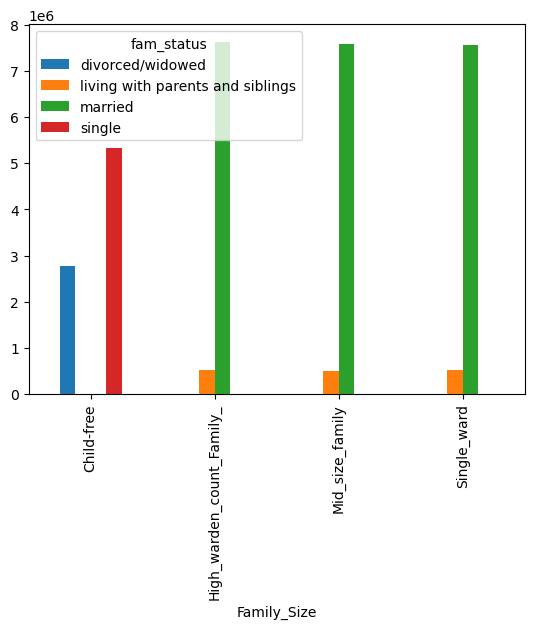

In [55]:
barplot_1=crosstab_1.plot.bar()

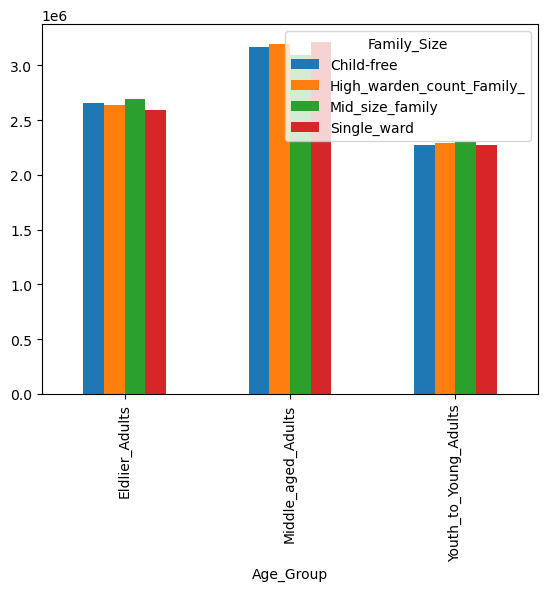

In [56]:
barplot_2=crosstab_2.plot.bar()

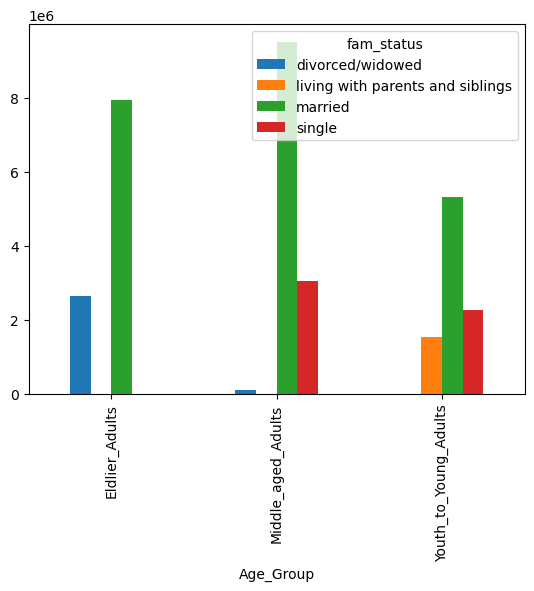

In [57]:
barplot_3=crosstab_3.plot.bar()

In [58]:
barplot_1.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\fam_size_status"))

In [59]:
barplot_2.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\age_group_household_size"))

In [60]:
barplot_3.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\age_group_mariatual_status"))

In [48]:
crosstab_4=pd.crosstab(df_1['income_loc'],df_1['Region'],dropna=False)

In [157]:
crosstab_4.head()

Region,Midwest,Northeast,SOUTH,West
income_loc,,,,
High-Income,16606,6857,12394,11835
Low-Income,4056466,3093489,5924868,4511215
Mid-Income,3522941,2621258,4852375,3768286


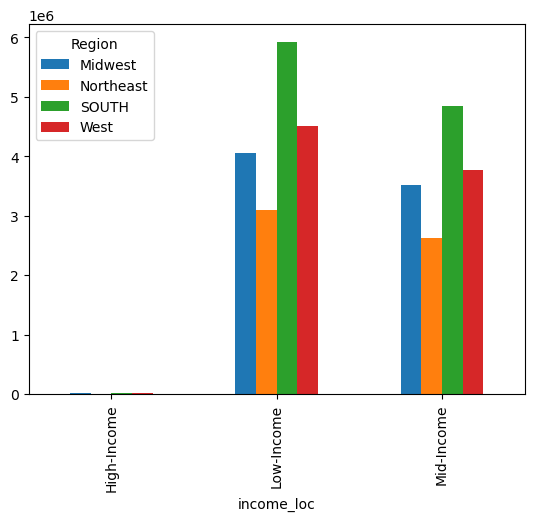

In [158]:
barplot_4=crosstab_4.plot.bar()

In [49]:
crosstab_5=pd.crosstab(df_1['Region'],df_1['Family_Size'],dropna=False)

In [65]:
crosstab_6=pd.crosstab(df_1['department_id'],df_1['product_name'],dropna=False)

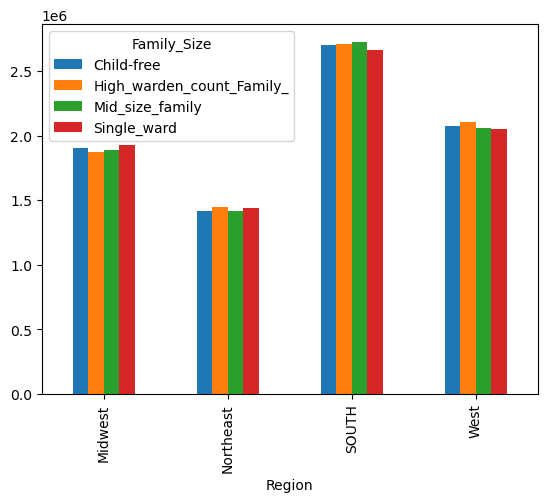

In [67]:
barplot_5=crosstab_5.plot.bar()

In [69]:
crosstab_5.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\region_family_size.csv"))

In [70]:
crosstab_6.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\department_product_name.csv"))

In [71]:
barplot_5.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\region_family_size"))

In [72]:
df_1.head(100)

,Unnamed: 0_x,order_id,user_id,order_number,orders_day_of_week,order_time,days_since_prior_order,product_id,add_to_cart_order,reordered,...,fam_status,income,Region,spender_mean,spending_flag,low_frequency_orders,low_order_frequency,Age_Group,income_loc,Family_Size
0,0,2539329,1,1,2,8,NaN,196,1,0,...,married,40423,SOUTH,6.367797,Low Spender,59,False,Youth_to_Young_Adults,NaN,High_warden_count_Family_
1,0,2539329,1,1,2,8,NaN,14084,2,0,...,married,40423,SOUTH,6.367797,Low Spender,59,False,Youth_to_Young_Adults,NaN,High_warden_count_Family_
2,0,2539329,1,1,2,8,NaN,12427,3,0,...,married,40423,SOUTH,6.367797,Low Spender,59,False,Youth_to_Young_Adults,NaN,High_warden_count_Family_
3,0,2539329,1,1,2,8,NaN,26088,4,0,...,married,40423,SOUTH,6.367797,Low Spender,59,False,Youth_to_Young_Adults,NaN,High_warden_count_Family_
4,0,2539329,1,1,2,8,NaN,26405,5,0,...,married,40423,SOUTH,6.367797,Low Spender,59,False,Youth_to_Young_Adults,NaN,High_warden_count_Family_
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,14,738281,2,4,2,10,8.0,21150,13,0,...,married,64940,West,7.515897,Low Spender,195,False,Eldlier_Adults,High-Income,High_warden_count_Family_
96,15,1673511,2,5,3,11,8.0,47144,1,0,...,married,64940,West,7.515897,Low Spender,195,False,Eldlier_Adults,High-Income,High_warden_count_Family_
97,15,1673511,2,5,3,11,8.0,5322,2,0,...,married,64940,West,7.515897,Low Spender,195,False,Eldlier_Adults,High-Income,High_warden_count_Family_
98,15,1673511,2,5,3,11,8.0,17224,3,0,...,married,64940,West,7.515897,Low Spender,195,False,Eldlier_Adults,High-Income,High_warden_count_Family_


In [73]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32398590 entries, 0 to 32404858
Data columns (total 40 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   Unnamed: 0_x            int64   
 1   order_id                int64   
 2   user_id                 int64   
 3   order_number            int64   
 4   orders_day_of_week      int64   
 5   order_time              int64   
 6   days_since_prior_order  float64 
 7   product_id              int64   
 8   add_to_cart_order       int64   
 9   reordered               int64   
 10  _merge                  category
 11  Unnamed: 0_y            int64   
 12  product_name            object  
 13  aisle_id                int64   
 14  department_id           int64   
 15  prices                  float64 
 16  merge_indicator         category
 17  price_range             object  
 18  price_range_loc         object  
 19  busiest_day             object  
 20  busiest_days            object  
 21  order_time_

In [75]:
path=r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Original data\departments.csv"

#dropping columns
'_merge, 0_y, 0_x'

In [50]:
df_1 = df_1.drop(columns = ['_merge'])

In [51]:
df_1 = df_1.drop(columns = ['Unnamed: 0_y'])

In [52]:
df_1 = df_1.drop(columns = ['Unnamed: 0_x'])

In [53]:
df_1 = df_1.drop(columns = ['merge_indicator'])

In [76]:
df_2=pd.read_csv(os.path.join(path))

In [83]:
df_2.head()

,department_id,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,department,frozen,other,bakery,produce,alcohol,international,beverages,pets,dry goods pasta,...,meat seafood,pantry,breakfast,canned goods,dairy eggs,household,babies,snacks,deli,missing


In [54]:
df_1.loc[df_1['department_id'] == 1, 'dep_loc'] = 'Frozen'

In [55]:
df_1.loc[df_1['department_id'] == 2, 'dep_loc'] = 'Other'

In [56]:
df_1.loc[df_1['department_id'] == 3, 'dep_loc'] = 'Bakery'

In [57]:
df_1.loc[df_1['department_id'] == 4, 'dep_loc'] = 'Produce'

In [58]:
df_1.loc[df_1['department_id'] == 5, 'dep_loc'] = 'Alcohol'

In [59]:
df_1.loc[df_1['department_id'] == 6, 'dep_loc'] = 'International'

In [60]:
df_1.loc[df_1['department_id'] == 7, 'dep_loc'] = 'Beverages'

In [61]:
df_1.loc[df_1['department_id'] == 8, 'dep_loc'] = 'Pets'

In [62]:
df_1.loc[df_1['department_id'] == 9, 'dep_loc'] = 'Dry goods Pasta'

In [63]:
df_1.loc[df_1['department_id'] == 11, 'dep_loc'] = 'Personal Care'

In [64]:
df_1.loc[df_1['department_id'] == 10, 'dep_loc'] = 'Bulk'

In [65]:
df_1.loc[df_1['department_id'] == 12, 'dep_loc'] = 'Meat & Seafood'

In [66]:
df_1.loc[df_1['department_id'] == 13, 'dep_loc'] = 'Pantry'

In [67]:
df_1.loc[df_1['department_id'] == 14, 'dep_loc'] = 'Breakfast'

In [68]:
df_1.loc[df_1['department_id'] == 15, 'dep_loc'] = 'Canned Goods'

In [69]:
df_1.loc[df_1['department_id'] == 16, 'dep_loc'] = 'Dairy & Eggs'

In [70]:
df_1.loc[df_1['department_id'] == 17, 'dep_loc'] = 'Household'

In [71]:
df_1.loc[df_1['department_id'] == 18, 'dep_loc'] = 'Babies'

In [72]:
df_1.loc[df_1['department_id'] == 19, 'dep_loc'] = 'Snacks'

In [73]:
df_1.loc[df_1['department_id'] == 20, 'dep_loc'] = 'Deli'

In [74]:
df_1.loc[df_1['department_id'] == 21, 'dep_loc'] = 'Nan'

In [75]:
#checking output
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32398590 entries, 0 to 32404858
Data columns (total 37 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   orders_day_of_week      int64  
 4   order_time              int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       int64  
 8   reordered               int64  
 9   product_name            object 
 10  aisle_id                int64  
 11  department_id           int64  
 12  prices                  float64
 13  price_range             object 
 14  price_range_loc         object 
 15  busiest_day             object 
 16  busiest_days            object 
 17  order_time_loc          object 
 18  time_of_order           object 
 19  max_order               int64  
 20  loyalty_flag            object 
 21  Gender                  object 
 2

In [76]:
crosstab_7=pd.crosstab(df_1['Region'],df_1['dep_loc'],dropna=False)

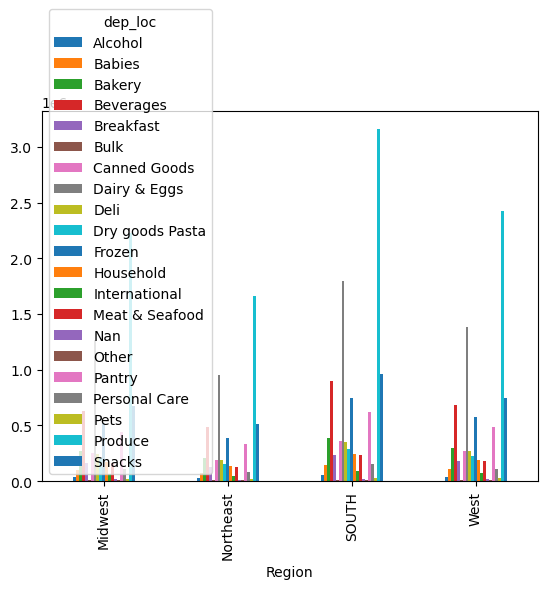

In [77]:
barplot_7=crosstab_7.plot.bar()

In [78]:
crosstab_8=pd.crosstab(df_1['Age_Group'],df_1['dep_loc'],dropna=False)

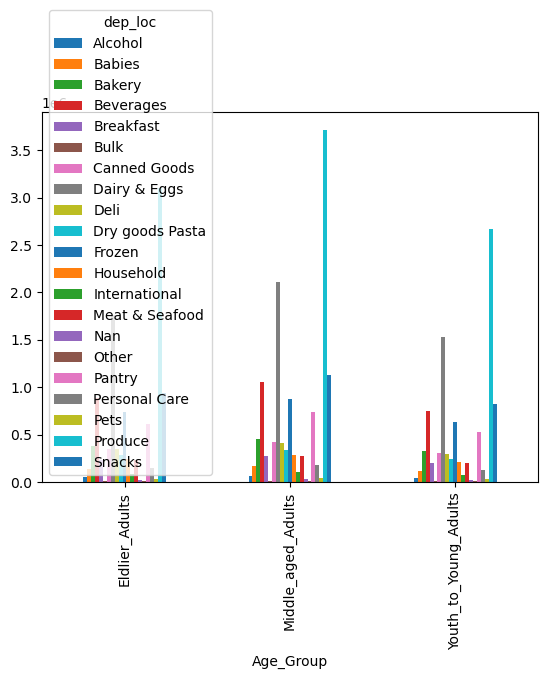

In [79]:
barplot_8=crosstab_8.plot.bar()

In [80]:
#Had to figure out how to move the legend off the chart

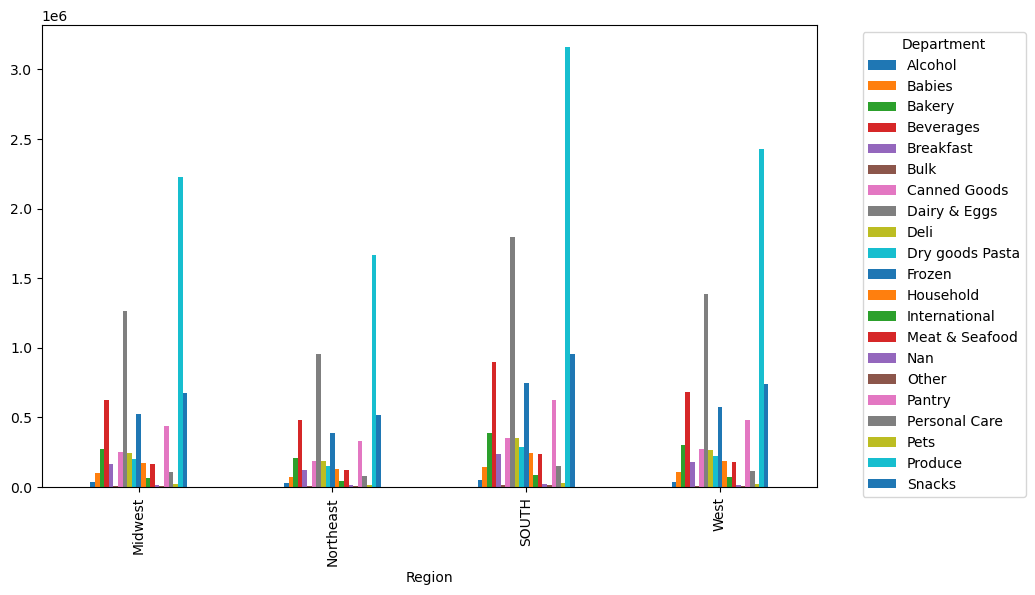

In [81]:
barplot_7=crosstab_7.plot.bar(figsize=(10,6))
plt.legend(title='Department',bbox_to_anchor=(1.05,1),loc='upper left')

In [82]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

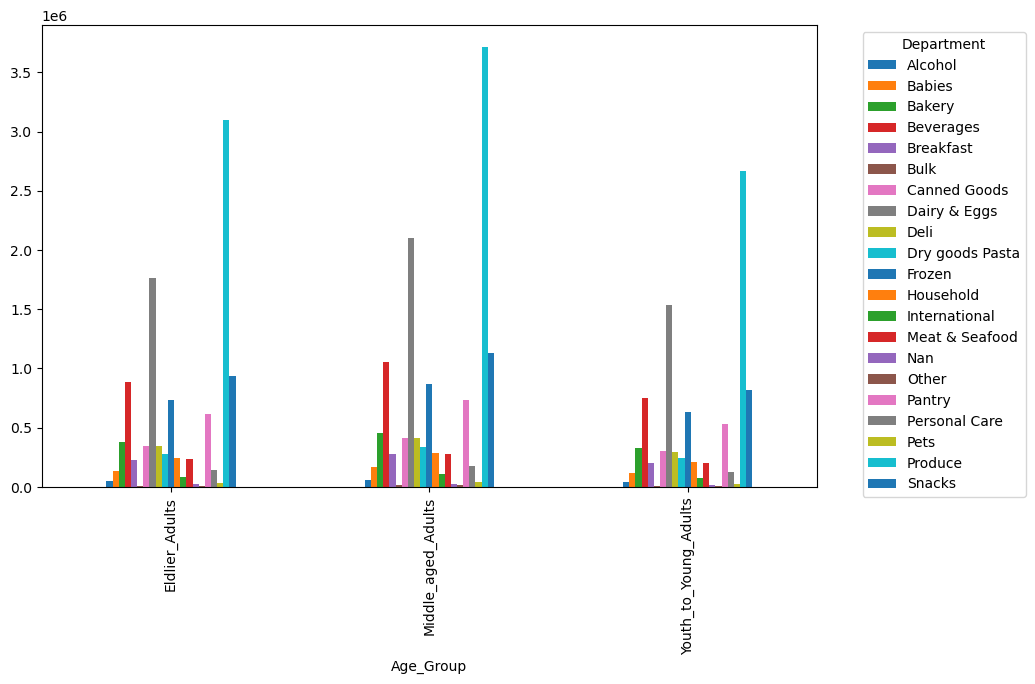

In [83]:
barplot_8=crosstab_8.plot.bar(figsize=(10,6))
plt.legend(title='Department',bbox_to_anchor=(1.05,1),loc='upper left')

In [84]:
barplot_7.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\region_department"))

In [85]:
barplot_8.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\age_department"))

In [86]:
crosstab_9=pd.crosstab(df_1['income_loc'],df_1['dep_loc'],dropna=False)

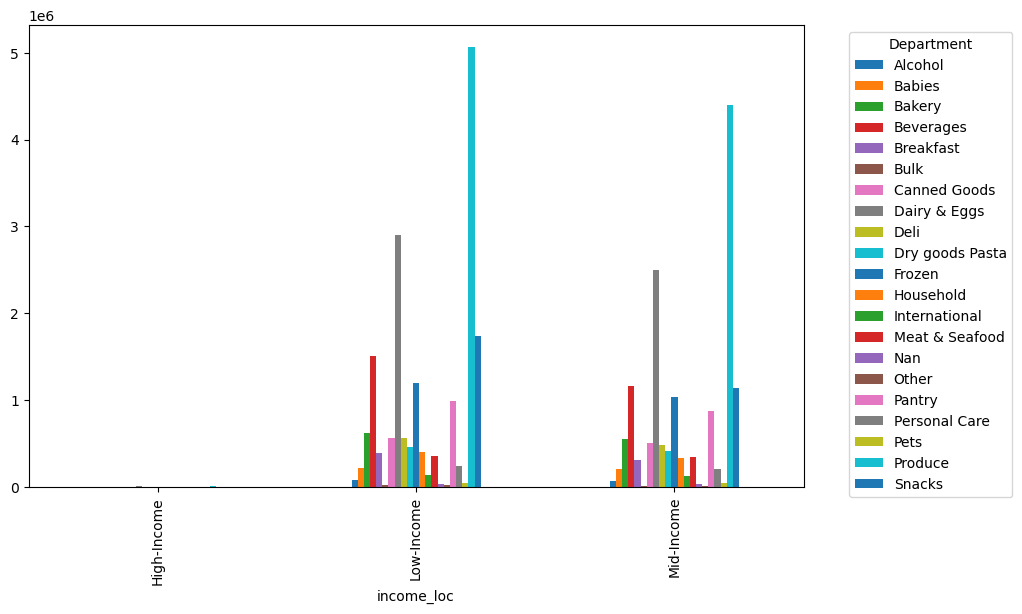

In [87]:
barplot_9=crosstab_9.plot.bar(figsize=(10,6))
plt.legend(title='Department',bbox_to_anchor=(1.05,1),loc='upper left')

In [88]:
crosstab_10=pd.crosstab(df_1['Family_Size'],df_1['dep_loc'],dropna=False)

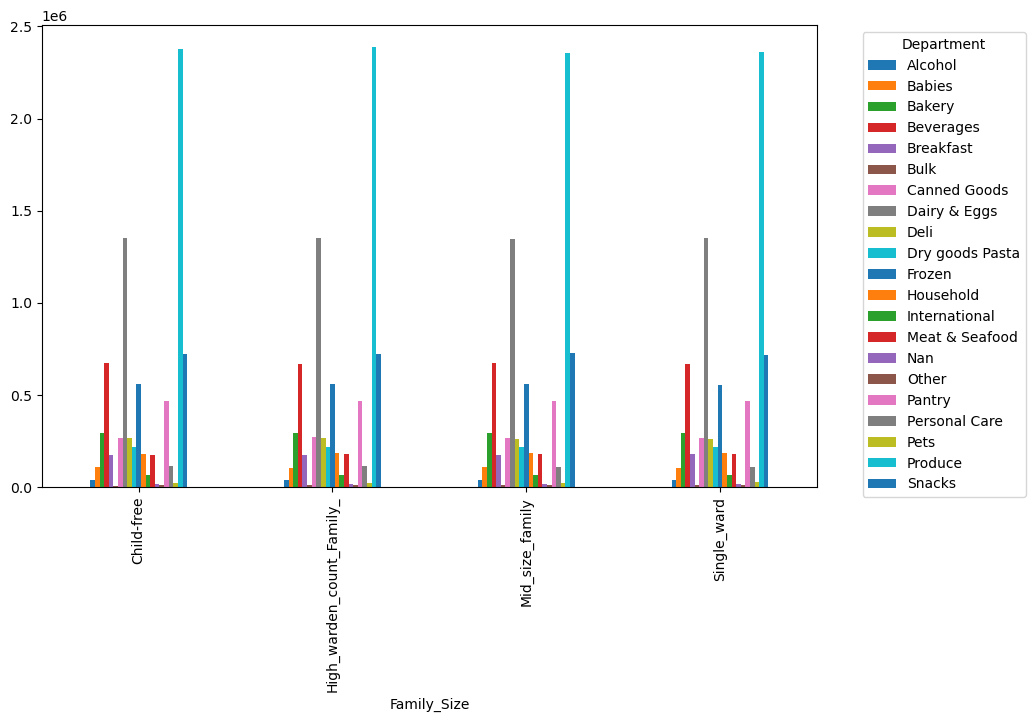

In [89]:
barplot_10=crosstab_10.plot.bar(figsize=(10,6))
plt.legend(title='Department',bbox_to_anchor=(1.05,1),loc='upper left')

In [90]:
barplot_9.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\income_department"))

In [91]:
barplot_10.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\family_size_department"))

In [92]:
crosstab_11=pd.crosstab(df_1['order_time_loc'],df_1['Age_Group'],dropna=False)

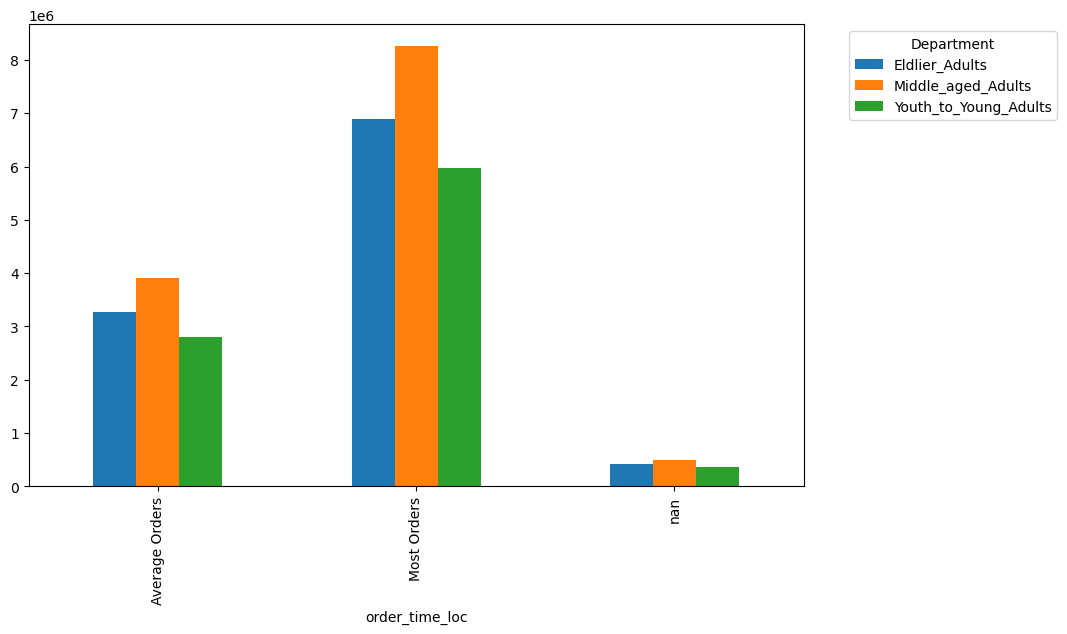

In [93]:
barplot_11=crosstab_11.plot.bar(figsize=(10,6))
plt.legend(title='Department',bbox_to_anchor=(1.05,1),loc='upper left')

In [94]:
barplot_11.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\order_time_age"))

In [96]:
crosstab_13=pd.crosstab(df_1['Region'],df_1['Age_Group'],dropna=False)

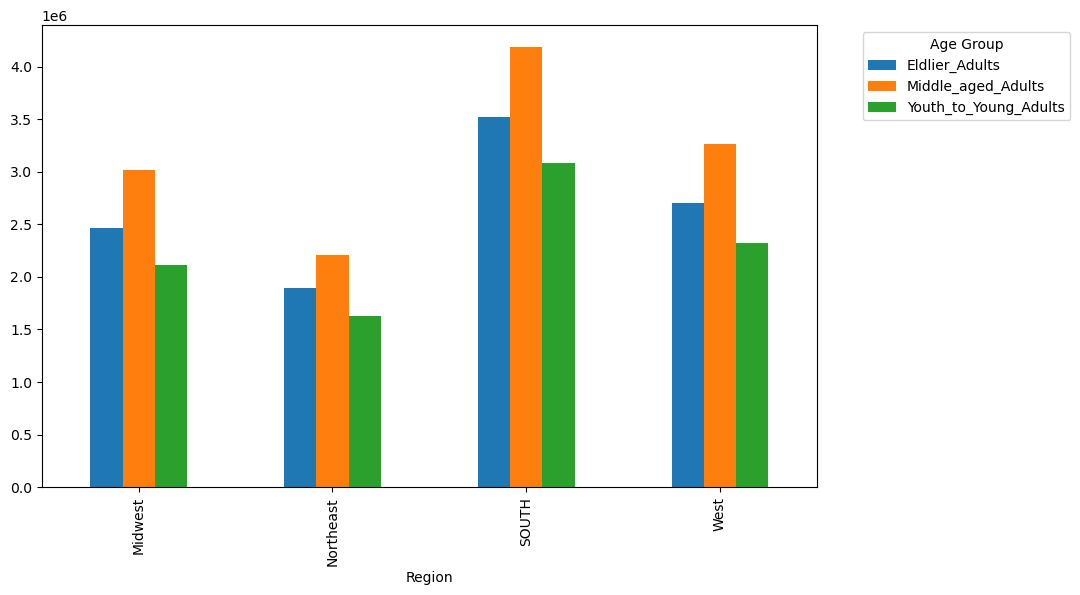

In [97]:
barplot_13=crosstab_13.plot.bar(figsize=(10,6))
plt.legend(title='Age Group',bbox_to_anchor=(1.05,1),loc='upper left')

In [98]:
barplot_13.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\bar_region_age"))

In [99]:
#Next Step of Task 

Aggregate the max, mean, and min variables on a customer-profile level for usage frequency and expenditure.

In [100]:
df_agg=df_1.groupby('Age_Group')['spender_mean'].agg(['max','mean','min'])

In [101]:
df_agg

,max,mean,min
Age_Group,,,
Eldlier_Adults,14042.512281,11.846816,1.2625
Middle_aged_Adults,15006.940000,11.980736,1.1000
Youth_to_Young_Adults,12506.925000,12.126119,1.0000


In [102]:
df_d=df_1[:2000000]

In [103]:
df_d1 = df_d.drop(df_d[(df_d['prices']==99999.0) | (df_d['prices']==14900.0)].index)

In [104]:
df_agg2=df_d1.groupby('Age_Group').agg({'prices': ['mean', 'min', 'max']})

In [105]:
df_agg2

prices           
                           mean  min   max
Age_Group                                 
Eldlier_Adults         7.800665  1.0  25.0
Middle_aged_Adults     7.760119  1.0  25.0
Youth_to_Young_Adults  7.789157  1.0  25.0

In [106]:
df_agg3=df_d1.groupby('Age_Group').agg({'order_number': ['mean', 'min', 'max']})

In [107]:
df_agg3

order_number        
                              mean min max
Age_Group                                 
Eldlier_Adults           17.159017   1  99
Middle_aged_Adults       17.081144   1  99
Youth_to_Young_Adults    17.714422   1  99

In [108]:
df_agg4=df_d1.groupby('fam_status').agg({'prices': ['mean', 'min', 'max']})

In [109]:
df_agg4

prices           
                                      mean  min   max
fam_status                                           
divorced/widowed                  7.848067  1.0  25.0
living with parents and siblings  7.771597  1.0  25.0
married                           7.777112  1.0  25.0
single                            7.766639  1.0  25.0

In [110]:
df_agg5=df_d1.groupby('fam_status').agg({'order_number': ['mean', 'min', 'max']})

In [111]:
df_agg5

order_number        
                                         mean min max
fam_status                                           
divorced/widowed                    18.085403   1  99
living with parents and siblings    17.465445   1  99
married                             17.243616   1  99
single                              16.949577   1  99

In [112]:
df_agg6=df_d1.groupby('Family_Size').agg({'prices': ['mean', 'min', 'max']})

In [113]:
df_agg6

prices           
                               mean  min   max
Family_Size                                   
Child-free                 7.796489  1.0  25.0
High_warden_count_Family_  7.780864  1.0  25.0
Mid_size_family            7.745089  1.0  25.0
Single_ward                7.806218  1.0  25.0

In [114]:
df_agg7=df_d1.groupby('Region').agg({'prices':['mean','min','max']})

In [115]:
df_agg7

prices           
               mean  min   max
Region                        
Midwest    7.763939  1.0  25.0
Northeast  7.789189  1.0  25.0
SOUTH      7.774629  1.0  25.0
West       7.801248  1.0  25.0

In [116]:
df_agg8=df_d1.groupby('Region').agg({'order_number':['mean','min','max']})

In [117]:
df_agg8

order_number        
                  mean min max
Region                        
Midwest      17.021194   1  99
Northeast    17.496376   1  99
SOUTH        17.375505   1  99
West         17.262372   1  99

In [118]:
df_agg9=df_d1.groupby('dep_loc').agg({'prices':['mean','min','max']})

In [119]:
df_agg9

prices           
                      mean  min   max
dep_loc                              
Alcohol           8.274190  1.0  15.0
Babies            7.716407  1.0  15.0
Bakery            7.843881  1.0  15.0
Beverages         7.725442  1.0  15.0
Breakfast         8.023296  1.0  14.9
Bulk              8.245545  1.4  14.1
Canned Goods      7.538176  1.0  15.0
Dairy & Eggs      8.330604  1.0  15.0
Deli              7.792786  1.0  15.0
Dry goods Pasta   7.407198  1.0  15.0
Frozen            7.750898  1.0  15.0
Household         7.362947  1.0  15.0
International     7.606422  1.0  15.0
Meat & Seafood   16.232484  8.0  25.0
Nan               8.562833  1.0  15.0
Other             6.631870  1.1  14.9
Pantry            7.970913  1.0  20.0
Personal Care     7.991614  1.0  15.0
Pets              7.779809  1.1  15.0
Produce           7.996845  1.0  15.0
Snacks            4.263885  1.6   7.0

In [120]:
df_agg10=df_d1.groupby('dep_loc').agg({'order_number':['mean','min','max']})

In [121]:
df_agg10

order_number        
                        mean min max
dep_loc                             
Alcohol            14.446356   1  99
Babies             19.970648   1  99
Bakery             17.726684   1  99
Beverages          17.562607   1  99
Breakfast          17.203545   1  99
Bulk               20.151665   1  99
Canned Goods       16.059471   1  99
Dairy & Eggs       17.756568   1  99
Deli               16.851508   1  99
Dry goods Pasta    16.015221   1  99
Frozen             15.226158   1  99
Household          16.203358   1  99
International      16.013240   1  99
Meat & Seafood     15.984750   1  99
Nan                22.527548   1  99
Other              17.460448   1  99
Pantry             16.635735   1  99
Personal Care      16.317446   1  99
Pets               15.014390   1  98
Produce            17.970852   1  99
Snacks             17.278885   1  99

In [122]:
df_agg11 = df_d1.groupby('Region').agg({'dep_loc': ['count', 'first', 'last']})


In [123]:
df_agg11

dep_loc                         
            count         first       last
Region                                    
Midwest    468680       Produce     Snacks
Northeast  362685  Dairy & Eggs       Deli
SOUTH      656739     Beverages  Beverages
West       511560        Snacks  Household

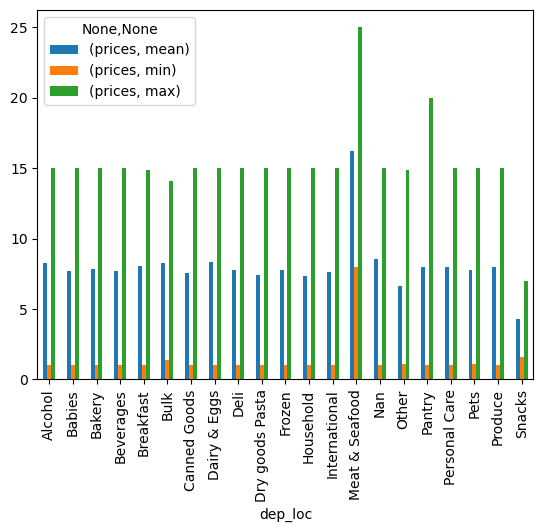

In [124]:
bar_9=df_agg9.plot.bar()

In [125]:
#safe bar chart
bar_9.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\department_pricing_levels"))

<Axes: xlabel='Age_Group'>

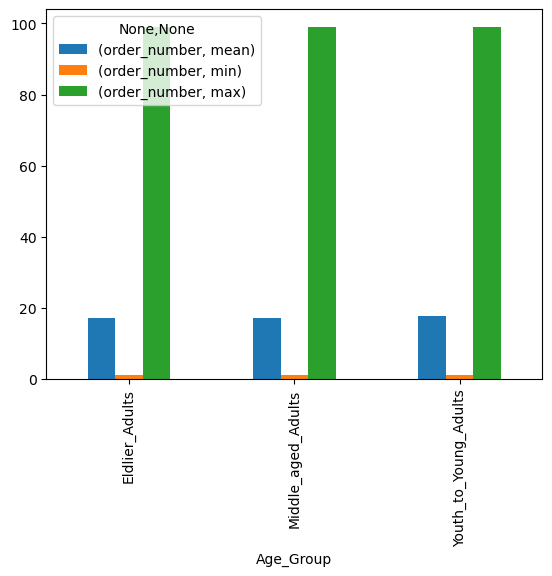

In [126]:
df_agg3.plot.bar()

<Axes: xlabel='Age_Group'>

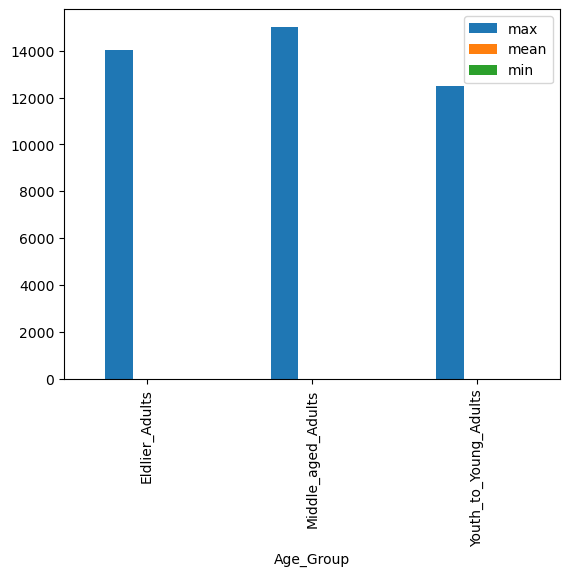

In [127]:
df_agg.plot.bar()

<Axes: xlabel='Region'>

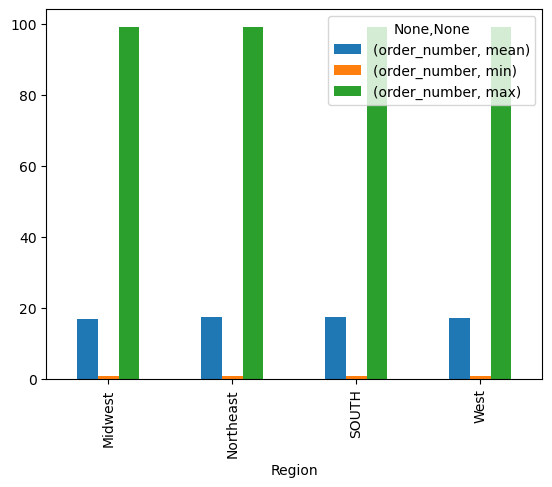

In [128]:
df_agg8.plot.bar()

In [129]:
#Exporting Crosstabs

In [130]:
crosstab_7.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\region_department.csv"))

In [131]:
crosstab_8.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\age_group_department.csv"))

In [132]:
crosstab_9.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\income_department.csv"))

In [133]:
crosstab_10.to_csv(os.path.join(path,r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\02 Data\Prepared Data\Department_family_size.csv"))

In [134]:
#Using a smaller subset to create less computing issues

In [135]:
df_3=df_1[:2000000]

In [136]:
#sampling the data to create Line charts
np.random.seed(4)
dev = np.random.rand(len(df_3)) <= 0.8

In [137]:
big=df_3[dev]

In [138]:
small=df_3[~dev]

In [139]:
#checking consistency
len(df_3)

2000000

In [140]:
len(big)+len(small)

2000000

In [141]:
df_income = small[['income_loc','user_id']]

In [142]:
df_time=small[['Age','order_time']]

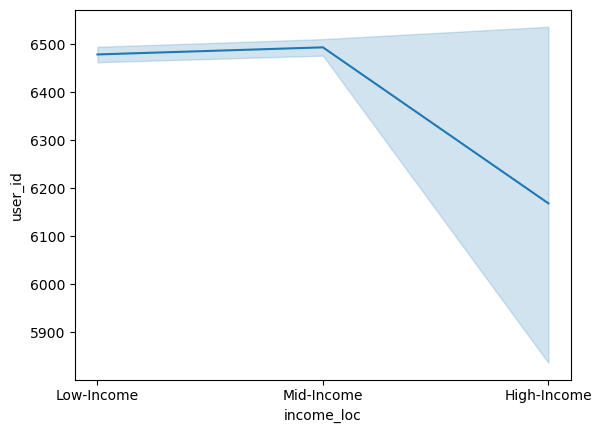

In [143]:
line = sns.lineplot(data = df_income, x = 'income_loc',y = 'user_id')

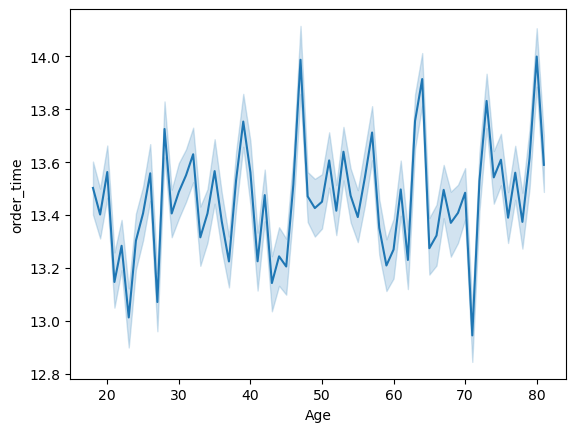

In [144]:
line_1 = sns.lineplot(data = df_time, x ='Age',y = 'order_time')

In [145]:
df_order=small[['order_time','order_number']]

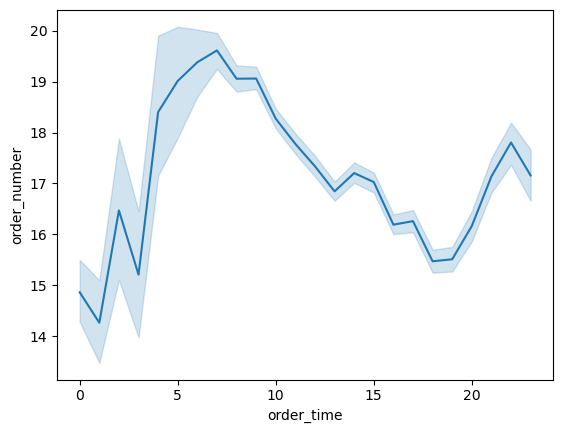

In [146]:
line_2 = sns.lineplot(data = df_order, x = 'order_time',y = 'order_number')

In [147]:
#safe line chart
line_2.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\order_time"))

In [148]:
df_reg=small[['Region','dep_loc']]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Beverages'),
  Text(1, 0, 'Snacks'),
  Text(2, 0, 'Dairy & Eggs'),
  Text(3, 0, 'Produce'),
  Text(4, 0, 'Deli'),
  Text(5, 0, 'Frozen'),
  Text(6, 0, 'Breakfast'),
  Text(7, 0, 'Personal Care'),
  Text(8, 0, 'Meat & Seafood'),
  Text(9, 0, 'International'),
  Text(10, 0, 'Pantry'),
  Text(11, 0, 'Canned Goods'),
  Text(12, 0, 'Babies'),
  Text(13, 0, 'Household'),
  Text(14, 0, 'Bakery'),
  Text(15, 0, 'Pets'),
  Text(16, 0, 'Dry goods Pasta'),
  Text(17, 0, 'Alcohol'),
  Text(18, 0, 'Other'),
  Text(19, 0, 'Nan'),
  Text(20, 0, 'Bulk')])

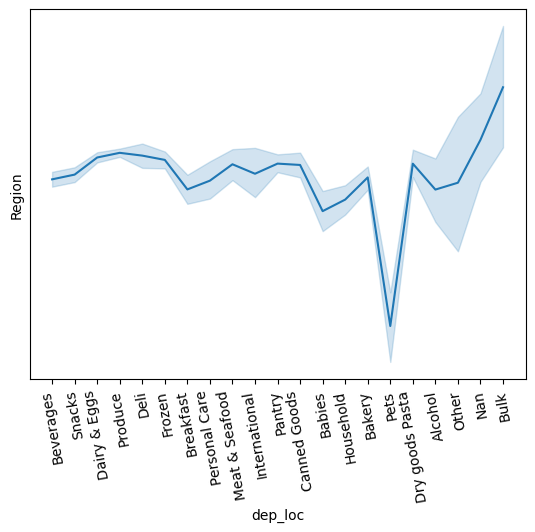

In [149]:
line_3 = sns.lineplot(data = df_reg, x = 'dep_loc',y = 'Region')
plt.xticks(rotation=100)

In [150]:
df_or_dep=small[['dep_loc','order_number']]

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'Beverages'),
  Text(1, 0, 'Snacks'),
  Text(2, 0, 'Dairy & Eggs'),
  Text(3, 0, 'Produce'),
  Text(4, 0, 'Deli'),
  Text(5, 0, 'Frozen'),
  Text(6, 0, 'Breakfast'),
  Text(7, 0, 'Personal Care'),
  Text(8, 0, 'Meat & Seafood'),
  Text(9, 0, 'International'),
  Text(10, 0, 'Pantry'),
  Text(11, 0, 'Canned Goods'),
  Text(12, 0, 'Babies'),
  Text(13, 0, 'Household'),
  Text(14, 0, 'Bakery'),
  Text(15, 0, 'Pets'),
  Text(16, 0, 'Dry goods Pasta'),
  Text(17, 0, 'Alcohol'),
  Text(18, 0, 'Other'),
  Text(19, 0, 'Nan'),
  Text(20, 0, 'Bulk')])

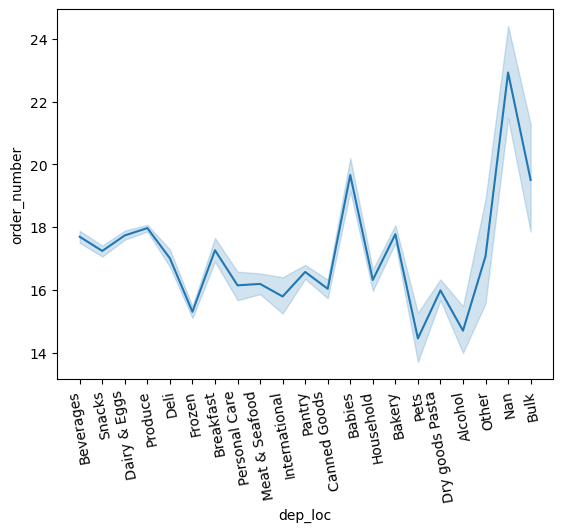

In [151]:
#corrected visual
line_4 = sns.lineplot(data=df_or_dep, x='dep_loc', y='order_number')
plt.xticks(rotation=100)

In [152]:
line_4.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\order_department_line"))

In [153]:
line_3.figure.savefig(os.path.join(path, r"C:\Users\neuma\OneDrive\Desktop\Instacart Basket Anlysis\04 Analysis\Visualization\department_region_line"))

In [155]:
df_1.to_pickle(os.path.join(path, "C:\\Users\\neuma\\OneDrive\\Desktop\\Instacart Basket Anlysis\\02 Data\\Prepared Data\\df_prods_ords_cust_final.pkl"))

In [9]:
df.rename(columns={'STATE':'State'}, inplace=True)